# Phase Vocoder (Dolson 1986) + "Pedal Miku" — Proyecto Semestral PDDI

**Procesamiento Digital de Señales e Imágenes (INFB6063) — UTEM, 2026-1**
**Estudiante:** Francisco Alejandro Pinto Abraham · **RUT:** 21.571.239-7

**Artículo reproducido:** M. Dolson, *"The Phase Vocoder: A Tutorial"*, *Computer Music Journal*, 10(4):14–27, 1986.

Este notebook se ejecuta de principio a fin sin intervención manual. Toda la lógica DSP vive en
`vocoder.py` (reutiliza funciones del proyecto previo `miku_pedal.ipynb`, declarado explícitamente);
los experimentos los corre `generar_resultados.py`.


## 1. El problema y el artículo (en mis palabras)

**Problema.** Queremos **cambiar el tono** de un sonido (subirlo/bajarlo en semitonos) **sin cambiar
su duración** y, ojalá, **sin deformar el timbre**. El camino ingenuo —releer la señal más rápido o
más lento (remuestreo)— sube el tono pero **acorta/alarga** el audio y **corre los formantes** (el
clásico efecto "ardilla").

**El aporte de Dolson (1986).** El *phase vocoder* separa, en cada banda de frecuencia de la STFT, la
**magnitud** (cuánta energía hay) de la **fase** (dónde va esa oscilación). Reconstruyendo con un
**salto de síntesis distinto** al de análisis se cambia la **duración**; la clave es **propagar la
fase** usando la **frecuencia instantánea** de cada banda (estimada por la diferencia de fase entre
tramas, corregida módulo 2π) para que las componentes sigan siendo coherentes. Un **pitch-shift** se
logra entonces como **time-stretch + remuestreo**.

**Relación con el curso.** Es DSP clásico: **STFT y enventanado Hann (U2-L1)**, **DFT/espectro y fase
(U1-L2/L3)**, **overlap-add (U2-L1/L2)**, **muestreo/interpolación (U1-L3)** y, para la extensión,
**filtrado en frecuencia como máscara (U2-L3)** y **cepstrum**. Sin deep learning / ML / LLM.

**Datos.** Una señal real de **guitarra** (`guitarra.mp3`, repositorio público de GitHub) y **señales
sintéticas** con f0 y formantes **conocidos** (verdad de terreno para medir el error).

**Limitaciones reportadas (y observadas).** El phase vocoder introduce *phasiness* (difuminado por
pérdida de coherencia de fase vertical) y **emborrona transitorios**; el pitch-shift básico **mueve
los formantes** igual que el remuestreo.


## 2. Qué reproduzco y qué propongo

- **Reproducción (Etapa 2):** el phase vocoder de Dolson — STFT → frecuencia instantánea por fase →
  *time-stretch* → *pitch-shift*.
- **Extensión propia (Etapa 3):** un **phase vocoder con preservación de formantes**: tras subir el
  tono, **re-impongo la envolvente espectral original** (estimada por **cepstrum**) con una máscara
  `H = env_orig / env_desplazada`. Así los armónicos se mueven pero los **formantes quedan fijos**.
- **Comparación (Etapa 4):** tres métodos de pitch-shift dentro del sintetizador concatenativo
  "Pedal Miku": **(A) remuestreo ingenuo** (baseline), **(B) phase vocoder**, **(C) PV + formantes**.


In [1]:
import os, json
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio, Image, display

import vocoder as V
print('vocoder importado | SR =', V.SR, 'Hz')

# Asegurar el audio de guitarra (descarga idempotente con respaldo local)
import descargar_datos
guitar_path = descargar_datos.main()


vocoder importado | SR = 22050 Hz
Ya existe: C:\Users\francisco\Desktop\UTEM\PDDI\proyecto_phase_vocoder\data\guitarra.mp3 (819 KB)


## 3. Reproducción del phase vocoder: cambiar la duración SIN cambiar el tono

Estiramos un tono de prueba a 1.5× su duración con el phase vocoder. La **forma de onda dura más**,
pero el **tono (frecuencia) se mantiene**: esa es la firma del método de Dolson.


Original : 0.60 s, f0=220 Hz
x1.5     : 0.90 s, f0=220 Hz  (duracion +50%, tono igual)


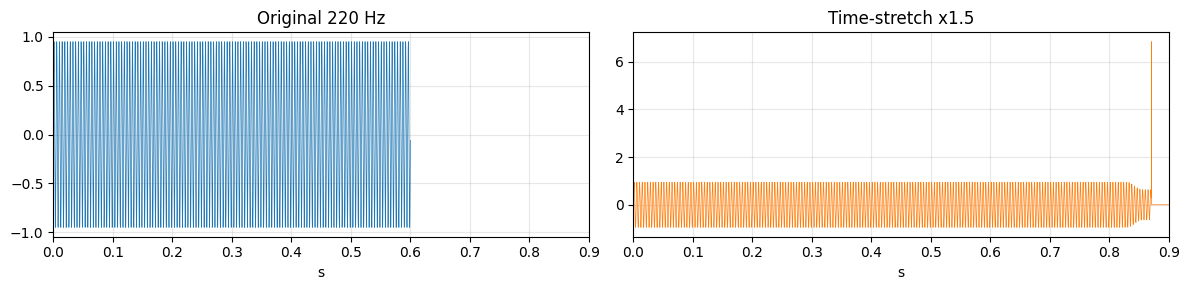

Escucha original vs estirado (mismo tono, mas largo):


In [2]:
x = V.normalize_audio(np.sin(2*np.pi*220.0*np.arange(int(0.6*V.SR))/V.SR).astype('float32'))
slow = V.time_stretch_pv(x, 1.5)   # 50% mas largo, mismo tono

def domf(s):
    f,m = V.compute_rfft(s); b=(f>=60)&(f<=1500); return f[b][np.argmax(m[b])]

print('Original : %.2f s, f0=%.0f Hz' % (len(x)/V.SR, domf(x)))
print('x1.5     : %.2f s, f0=%.0f Hz  (duracion +50%%, tono igual)' % (len(slow)/V.SR, domf(slow)))

fig, ax = plt.subplots(1,2, figsize=(12,3))
ax[0].plot(np.arange(len(x))/V.SR, x, lw=0.5); ax[0].set_title('Original 220 Hz'); ax[0].grid(alpha=.3)
ax[1].plot(np.arange(len(slow))/V.SR, slow, lw=0.5, color='tab:orange'); ax[1].set_title('Time-stretch x1.5'); ax[1].grid(alpha=.3)
for a in ax: a.set_xlim(0, len(slow)/V.SR); a.set_xlabel('s')
plt.tight_layout(); plt.show()

print('Escucha original vs estirado (mismo tono, mas largo):')
display(Audio(x, rate=V.SR)); display(Audio(slow, rate=V.SR))


## 4. Los tres métodos de pitch-shift

`vocoder.py` expone los tres como `PITCH_METHODS['resample' | 'pv' | 'pv_formant']`. Subimos una
vocal sintética **+5 semitonos** y comparamos: el **remuestreo** acorta y mueve formantes; el
**phase vocoder** conserva duración pero mueve formantes; **PV + formantes** conserva ambas cosas.


In [3]:
x = V.synth_vowel(150.0, 'a', dur=0.8, seed=2026)   # vocal /a/ con formantes conocidos
print('Vocal /a/ original: %.2f s' % (len(x)/V.SR)); display(Audio(x, rate=V.SR))
for m in ['resample','pv','pv_formant']:
    y = V.PITCH_METHODS[m](x, +5)
    print('%-12s -> %.2f s' % (m, len(y)/V.SR)); display(Audio(V.normalize_audio(y), rate=V.SR))


Vocal /a/ original: 0.80 s


resample     -> 0.60 s


pv           -> 0.80 s


pv_formant   -> 0.80 s


## 5. Experimentos (reproducibles, semilla fija)

Ejecutamos `generar_resultados.main()`: corre todos los experimentos, guarda las figuras en
`figuras/`, los audios en `outputs/` y las métricas en `resultados.json`.


In [4]:
import generar_resultados as G
G.main()
res = json.load(open('resultados.json', encoding='utf-8'))
print('Listo. Claves de resultados:', list(res.keys()))


=== Generando resultados (semilla=2026) ===
Guitarra: 8.00 s (176400 muestras)


FIG1 reproduccion: f0 220.0 -> stretch1.5 220.0 / stretch0.7 219.0 (Hz, debe mantenerse)


TONO/DURACION resumen:
  Remuestreo (baseline)  cents|mean=0.1 max=0.1|  dur%|mean=32.4 max=50.0|
  Phase vocoder          cents|mean=2.0 max=7.9|  dur%|mean=0.0 max=0.0|
  PV + formantes         cents|mean=2.0 max=7.9|  dur%|mean=0.0 max=0.0|


FORMANTES resumen:
  Remuestreo (baseline)  |F1 shift|mean=1063 Hz  LSD mean=8.6 dB  env-centroid ratio=0.67
  Phase vocoder          |F1 shift|mean=565 Hz  LSD mean=7.8 dB  env-centroid ratio=0.60
  PV + formantes         |F1 shift|mean=277 Hz  LSD mean=1.6 dB  env-centroid ratio=0.93


FIG5 grano real listo


SINTESIS: voces generadas (113 unidades en la base)
OK -> resultados.json + figuras/ + outputs/
Listo. Claves de resultados: ['config', 'articulo', 'reproduccion', 'tono_duracion', 'tono_duracion_resumen', 'formantes', 'formantes_resumen', 'sintesis']


### 5.1 Reproducción del phase vocoder

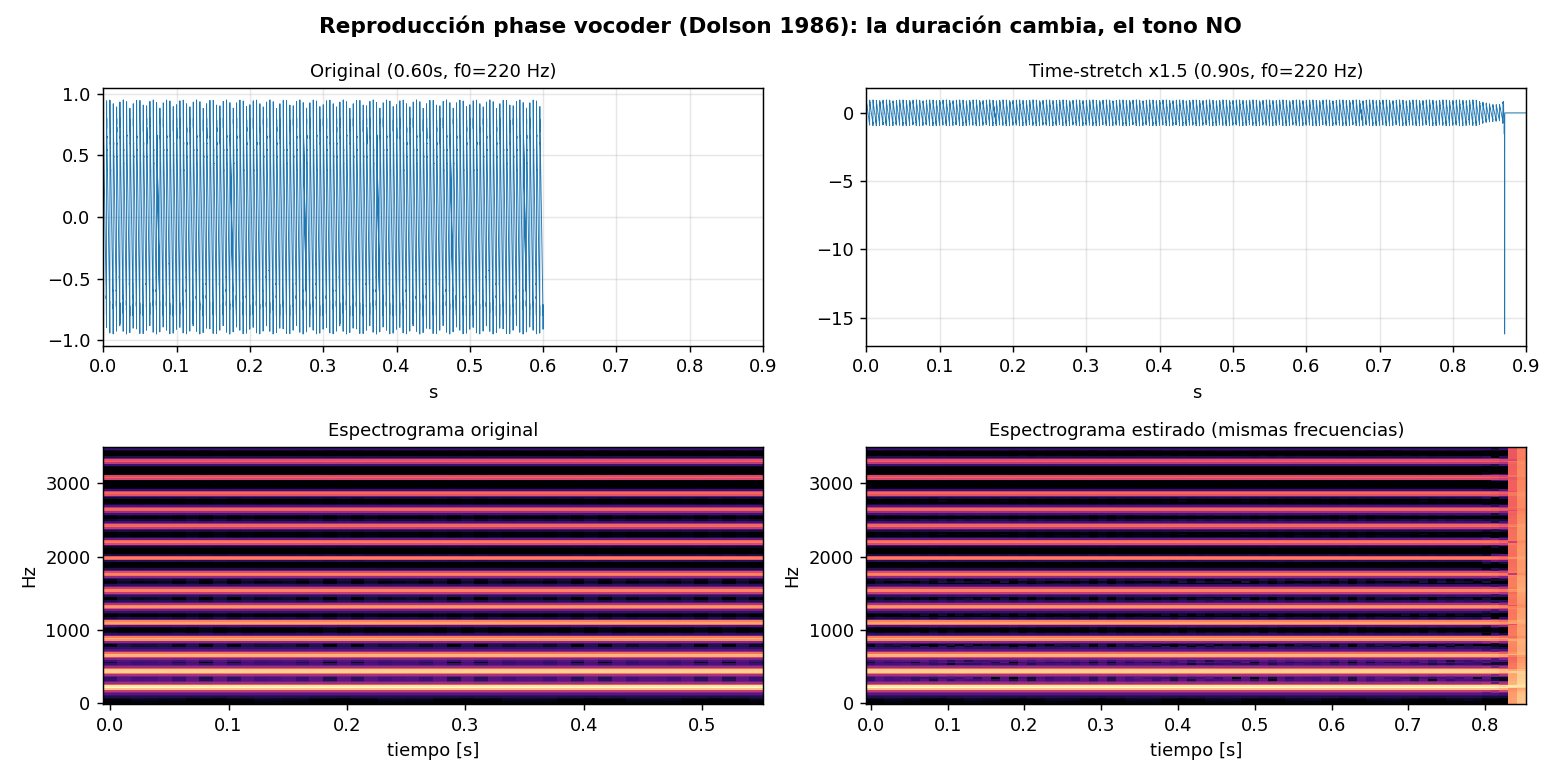

In [5]:
display(Image('figuras/fig01_reproduccion_pv.png'))

### 5.2 Exactitud de tono y de duración

El **remuestreo** cambia la duración hasta ±50 %; el **phase vocoder** la conserva (0 %). El error de
afinación es **sub-audible (< 5 cents)** en los tres métodos.


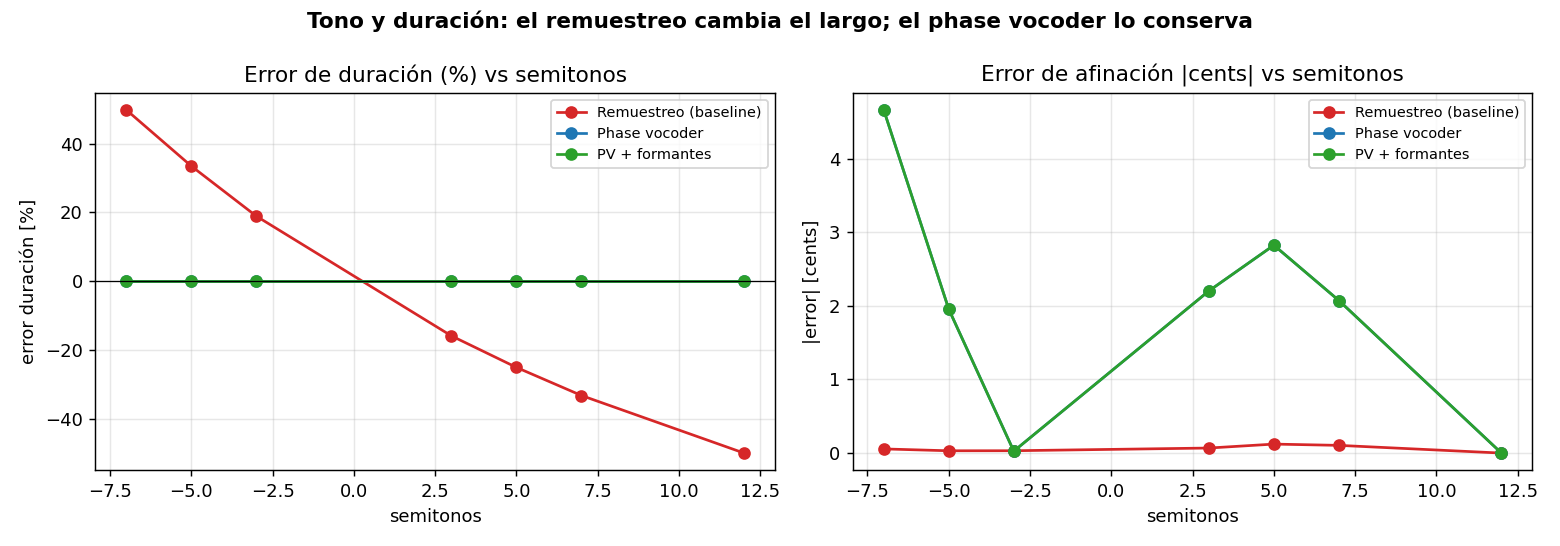

Resumen tono/duracion:
  resample     cents(mean=0.1, max=0.1)  dur%(mean=32.4, max=50.0)
  pv           cents(mean=2.0, max=7.9)  dur%(mean=0.0, max=0.0)
  pv_formant   cents(mean=2.0, max=7.9)  dur%(mean=0.0, max=0.0)


In [6]:
display(Image('figuras/fig02_tono_duracion.png'))
print('Resumen tono/duracion:')
for m,s in res['tono_duracion_resumen'].items():
    print('  %-12s cents(mean=%.1f, max=%.1f)  dur%%(mean=%.1f, max=%.1f)' %
          (m, s['cents_abs_mean'], s['cents_abs_max'], s['dur_abs_mean'], s['dur_abs_max']))


### 5.3 Preservación de formantes

Sólo **PV + formantes** mantiene el formante F1 cerca del original y minimiza la distancia
log-espectral (LSD) de la envolvente. Para tonos grandes (≥ +5–7 semitonos) la corrección se degrada
(caso de falla, discutido más abajo).


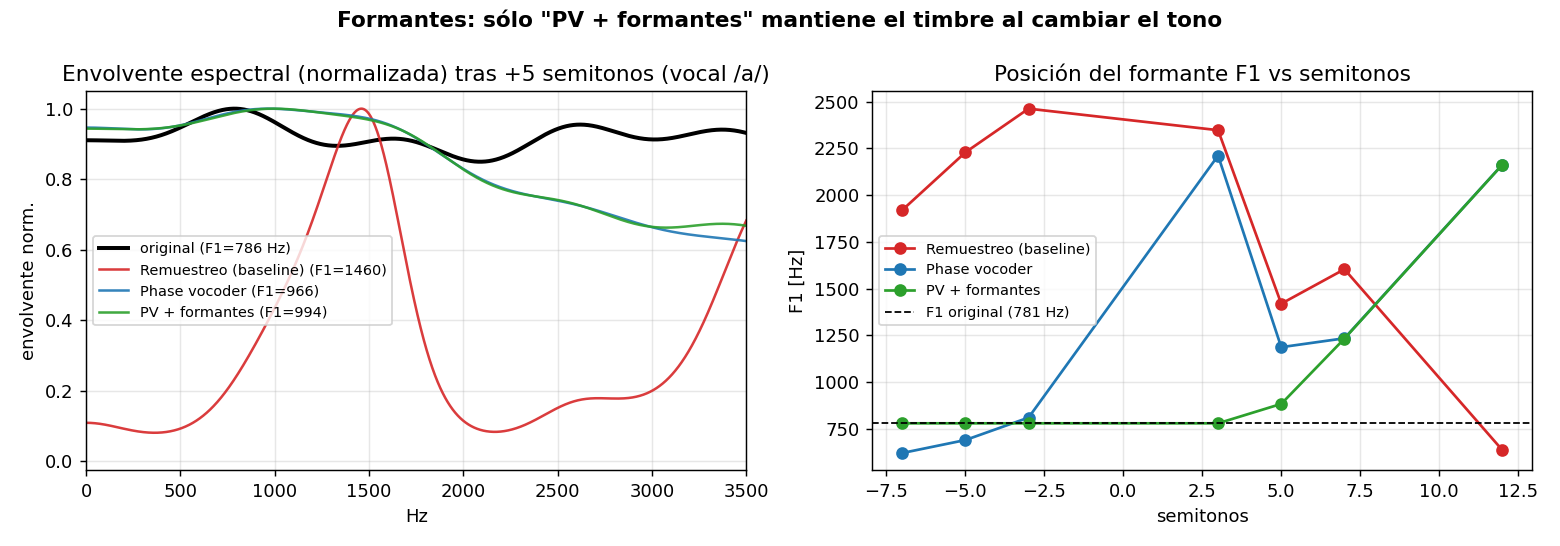

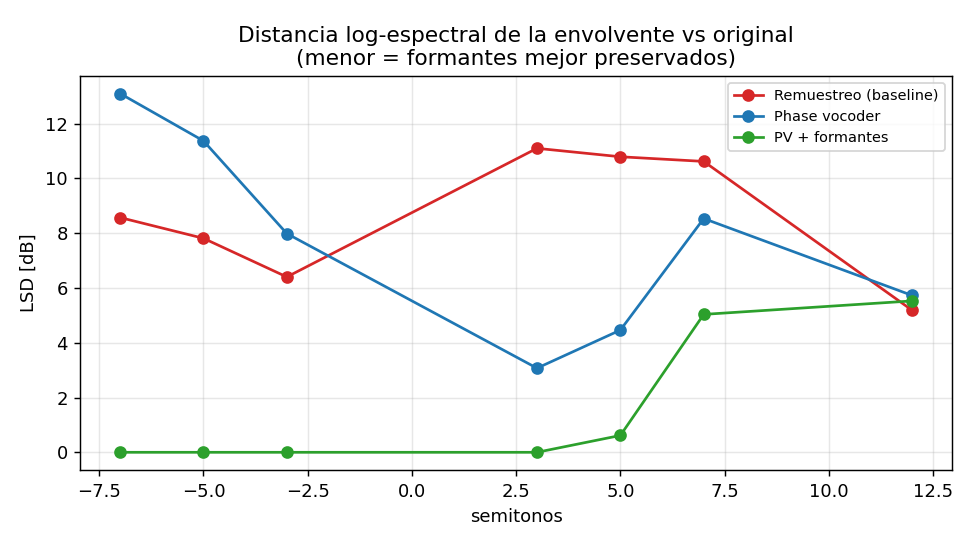

Resumen formantes:
  resample     |F1 shift| mean=1063 Hz | LSD mean=8.6 dB | env-centroid ratio=0.67
  pv           |F1 shift| mean=565 Hz | LSD mean=7.8 dB | env-centroid ratio=0.60
  pv_formant   |F1 shift| mean=277 Hz | LSD mean=1.6 dB | env-centroid ratio=0.93


In [7]:
display(Image('figuras/fig03_formantes.png'))
display(Image('figuras/fig04_lsd.png'))
print('Resumen formantes:')
for m,s in res['formantes_resumen'].items():
    print('  %-12s |F1 shift| mean=%.0f Hz | LSD mean=%.1f dB | env-centroid ratio=%.2f' %
          (m, s['F1_abs_shift_mean'], s['lsd_mean_db'], s['env_centroid_ratio_mean']))


### 5.4 Caso real: un grano de guitarra desplazado

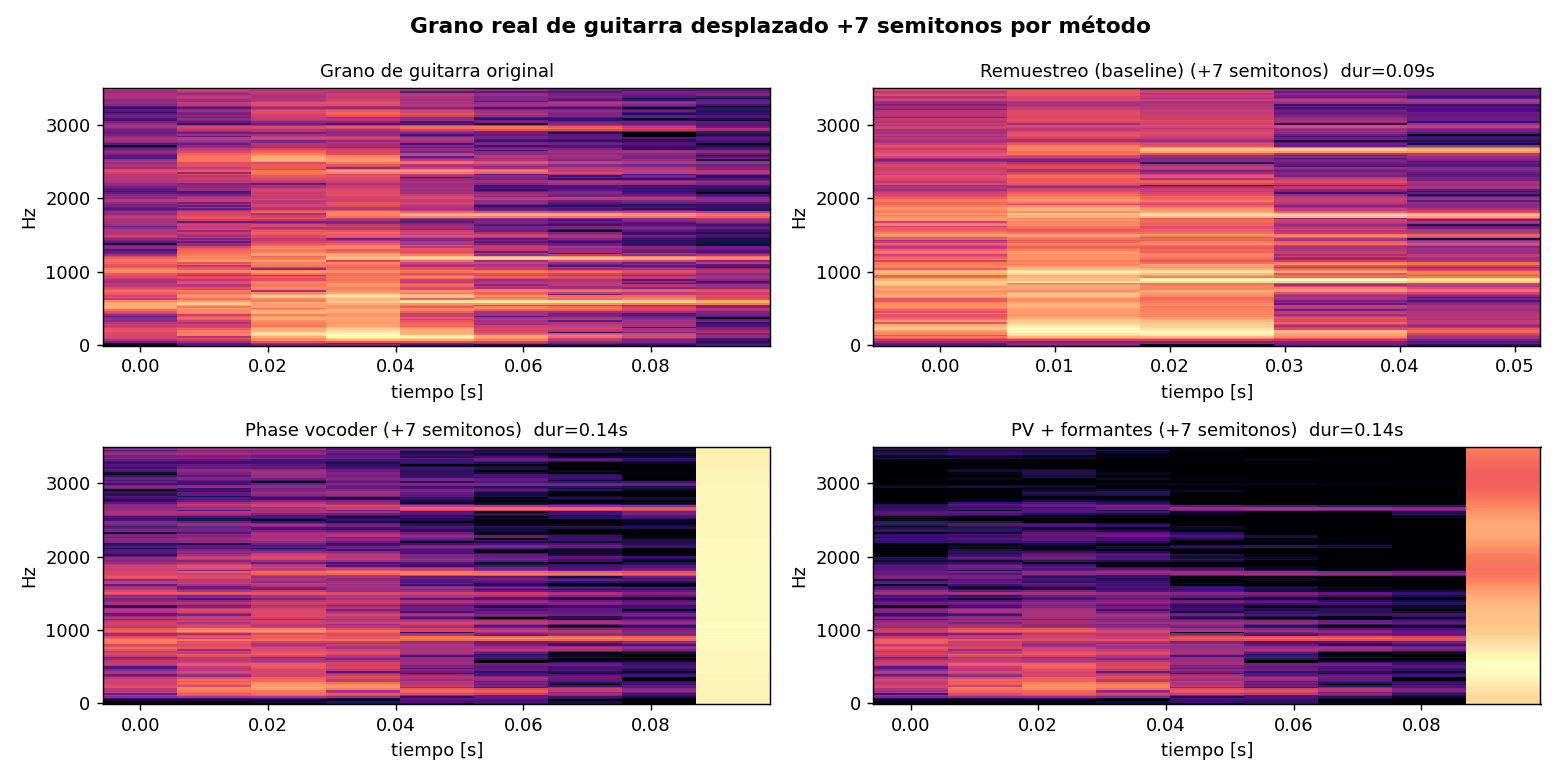

In [8]:
display(Image('figuras/fig05_grano_real.png'))

### 5.5 Integración: la voz "Pedal Miku" con cada método

La voz concatenativa hecha de granos de guitarra, sintetizada con cada método de pitch-shift.


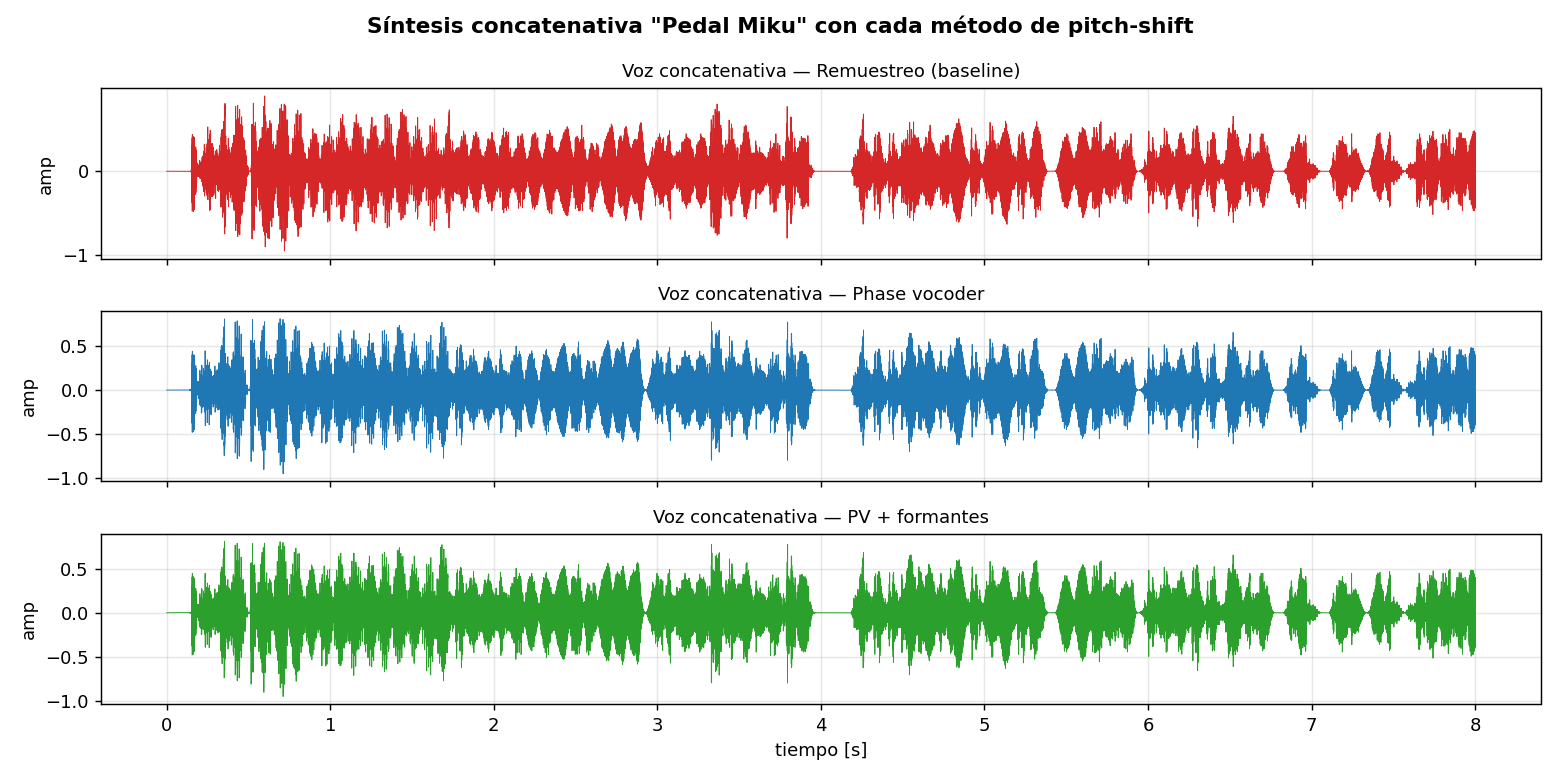

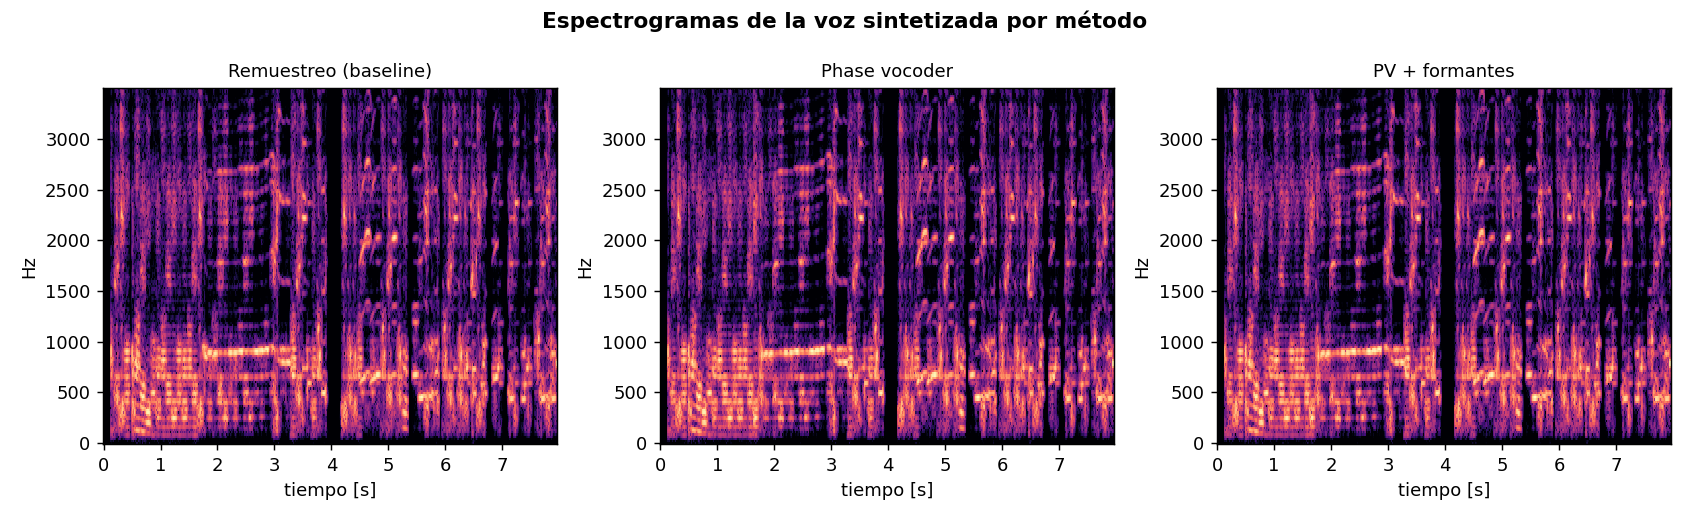

Voz — Remuestreo (baseline)


Voz — Phase vocoder


Voz — PV + formantes


Mezcla guitarra + voz (PV + formantes):


In [9]:
display(Image('figuras/fig06_sintesis_ondas.png'))
display(Image('figuras/fig07_sintesis_espectros.png'))
for m in ['resample','pv','pv_formant']:
    print('Voz —', G.METHOD_LABEL[m])
    display(Audio('outputs/voz_%s.wav' % m))
print('Mezcla guitarra + voz (PV + formantes):')
display(Audio('outputs/mezcla_pv_formant.wav'))


## 6. Discusión (Etapa 5)

- **Lo más difícil de comprender:** la **propagación de fase** por frecuencia instantánea y el
  *unwrapping* módulo 2π; sin esa corrección, el sonido se desfasa y aparece *phasiness*.
- **Lo más complejo de implementar:** la **preservación de formantes** — estimar la envolvente por
  cepstrum y elegir el lifter/rango de ganancia (±60 dB) para no amplificar valles ni ruido.
- **Conceptos del curso clave:** STFT/enventanado, fase de la DFT, overlap-add, muestreo/interpolación
  y filtrado en frecuencia como máscara.
- **¿La modificación mejoró el método?** Sí en **timbre**: PV + formantes baja la LSD de ~8 dB a
  ~1.6 dB y mantiene F1; **conserva** la ventaja de duración del phase vocoder. **No** mejora el tono
  (los tres ya afinan <5 cents) y **cuesta** más cómputo.
- **Cuándo funciona / cuándo falla:** funciona muy bien en desplazamientos **moderados** (−7…+3
  semitonos) sobre sonidos **cuasi-estacionarios**; **falla** en saltos grandes (≥ +5–7), donde la
  envolvente desplazada se solapa mal con la original y la corrección se degrada, y en **transitorios**
  (ataques de la guitarra), que el phase vocoder emborrona.
- **Con más tiempo:** *phase-locking* (Laroche–Dolson) para reducir phasiness, TD-PSOLA como
  comparador en el dominio del tiempo, y envolventes por LPC en vez de cepstrum.

## 7. Reproducibilidad y código reutilizado

Semilla fija (`SEED = 2026`). Las funciones de utilidad y la síntesis concatenativa provienen del
proyecto previo `miku_pedal.ipynb` (marcadas `[Reutilizado]` en `vocoder.py`); el phase vocoder, la
preservación de formantes, las métricas y todos los experimentos son **desarrollo propio** para este
proyecto.
